In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import tensorflow.compat.v2 as tf
import tensorflow_probability as tfp
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from tensorflow_probability.python.internal import tf_keras
from bayesian_ensamble.ensamble import confidence_prediction, plt_calibration_curve, bayesian_ensamble_predict, dynamic_threshold

In [2]:
tfd = tfp.distributions
IMAGE_SHAPE = [28, 28, 1]
NUM_TRAIN_EXAMPLES = 60000
NUM_HELDOUT_EXAMPLES = 10000
NUM_CLASSES = 10
def create_model():
    """Creates a Keras model using LeNet-5 architecture.
    
    Returns:
        model: Compiled Keras model.
    """

    kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /
                              tf.cast(NUM_TRAIN_EXAMPLES, dtype=tf.float32))
    
    model = tf_keras.models.Sequential([
        tfp.layers.Convolution2DFlipout(
            6, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.MaxPooling2D(
            pool_size=[2, 2], strides=[2,2],
            padding='SAME'),
        tfp.layers.Convolution2DFlipout(
            16, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.MaxPooling2D(
            pool_size=[2, 2], strides=[2, 2],
            padding='SAME'),
        tfp.layers.Convolution2DFlipout(
            120, kernel_size=5, padding='SAME',
            kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tf_keras.layers.Flatten(),
        tfp.layers.DenseFlipout(
            84, kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.relu),
        tfp.layers.DenseFlipout(
            NUM_CLASSES, kernel_divergence_fn=kl_divergence_function,
            activation=tf.nn.softmax)
    ])
    optimizer = tf_keras.optimizers.legacy.Adam(lr=0.001)
    model.compile(optimizer, loss= 'categorical_crossentropy',
                  metrics=['accuracy'], experimental_run_tf_function=False)
    return model

In [3]:
svm_linear = joblib.load('mnist_svm_linear.pkl')
svm_rbf = joblib.load('mnist_svm_non_linear.pkl')

bnn_model = create_model()
bnn_model.build(input_shape=[None, 28, 28, 1])
bnn_model.load_weights('final_model.keras')

model_dir = 'cnn_models'
model_list = [bnn_model, svm_rbf, svm_linear]

files = sorted([f for f in os.listdir(model_dir) if f.endswith('.keras')])

for filename in files:
    path = os.path.join(model_dir, filename)
    model_list.append(load_model(path))

print(f"{len(model_list)} model(s) ready for loading")


/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tf_keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tensorflow_probability/python/layers/util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-packages/tensorflow_probability/python/layers/util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
/Users/knganga1/Documents/Projects/discrete_math/learn tensorflow/.venv/lib/python3.13/site-pack

18 model(s) ready for loading


In [4]:
digits_train = pd.read_csv("input/svm/train.csv")
X = digits_train.iloc[:, 1:].values
Y = digits_train.iloc[:, 0].values
X = X/255.0

x_train, x_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
probs, _, _ = bayesian_ensamble_predict(model_list, x_val)

print("Stacking successful!")
print(f"Probabilities Shape: {probs.shape}")

best_threshold, _, _ = dynamic_threshold(probs, y_val, np.max(probs, axis=1))

final_results = confidence_prediction(x_test, model_list, best_threshold)

Model <tf_keras.src.engine.sequential.Sequential object at 0x1220ddbe0> output shape: (4200, 10)
<class 'sklearn.svm._classes.SVC'>
Model SVC(C=1, gamma=0.001, probability=True) output shape: (4200, 10)
<class 'sklearn.svm._classes.SVC'>
Model SVC(kernel='linear', probability=True) output shape: (4200, 10)
Model <Sequential name=sequential_16, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_17, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_26, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_27, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_28, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_29, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_30, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_18, built=True> output shape: (4200, 10)
Model <Sequential name=sequential_19, built=True> output shape: (4200, 10)
Model <Sequential

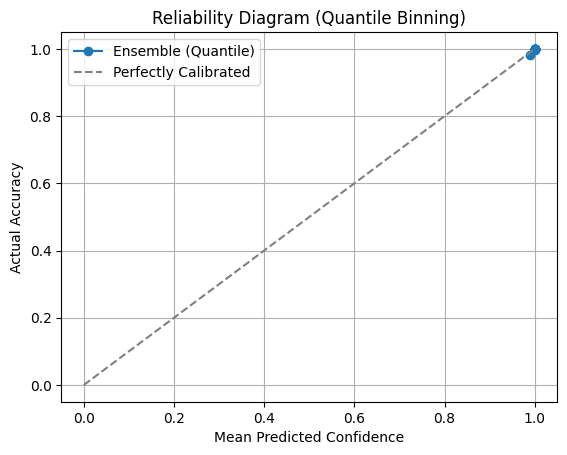

In [5]:
plt_calibration_curve(y_val, probs)